In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

# Control figure size
figsize=(14, 4)

from util import util
import os
import numpy as np
from tensorflow.keras import callbacks
from sklearn.metrics import r2_score
import warnings
warnings.simplefilter("ignore")

# Load data
data_folder = os.path.join('..', 'data')
data = util.load_data(data_folder)

# Identify input columns
dt_in = list(data.columns[3:-1]) # Exclude metadata

# RUL Prediction as Regression

<div class=big><small>Say we want to define a RUL-based maintenance policy</small><br>How would you tackle that problem?</div>

## RUL Prediction as Regression

**Let's start from _the simpler formulation_ of a RUL-based policy**

* We will predict the RUL using a regression approach
* ...And trigger maintenance when the estimated RUL becomes too low, i.e.:

$$
f(x, \theta) \leq \varepsilon
$$

* $f$ is the regressor, with parameter vector $\theta$
* The threshold $\varepsilon$ must account for possible estimation errors

**We will focus on the hardest of the four datasets (to reduce training times):**

In [2]:
data_by_src = util.split_by_field(data, field='src')
dt = data_by_src['train_FD004']

<div class=big><span style='font-size:0.8em'>We now need to define our training and test data</span><br/>How do we proceed?</div>

## Training and Test Data

**We now need to define our training and test data**

In a practical setting:

* Some run-to-failure experiments will form the training set
* Others run-to-failure experiments will be used for testing

I.e. we split _whole experiments_ rather than individual examples! 

**Each run-to-failure experiment in our data is associated to a machine**

Let's check how many we have:

In [3]:
print(f'Number of machines: {len(dt.machine.unique())}')

Number of machines: 249


* This is actually a _very large_ number
* In most practical setting, _much fewer_ experiments will be available

## Training and Test Data

**Let's use 75% of the machine for training, the rest for testing**

First, we partition the machine indexes:

In [4]:
tr_ratio = 0.75
np.random.seed(42)
machines = dt.machine.unique()
np.random.shuffle(machines)

sep = int(tr_ratio * len(machines))
tr_mcn = machines[:sep]
ts_mcn = machines[sep:]

Then, we partition the dataset itself (via a helper function):

In [5]:
tr, ts = util.partition_by_machine(dt, tr_mcn)

## Training and Test Data

**Let's have a look at the training data**

In [6]:
tr

,src,machine,cycle,p1,p2,p3,s1,s2,s3,s4,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,rul
0,train_FD004,461,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,...,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,320
1,train_FD004,461,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,319
2,train_FD004,461,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,318
3,train_FD004,461,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,317
4,train_FD004,461,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60989,train_FD004,708,180,35.0019,0.8409,100.0,449.44,556.28,1377.65,1148.96,...,2387.77,8048.91,9.4169,0.02,337,2223,100.00,14.66,8.7446,4
60990,train_FD004,708,181,0.0023,0.0000,100.0,518.67,643.95,1602.98,1429.57,...,2388.27,8122.44,8.5242,0.03,396,2388,100.00,38.40,23.1079,3
60991,train_FD004,708,182,25.0030,0.6200,60.0,462.54,536.88,1268.01,1067.09,...,2027.98,7865.18,10.9790,0.02,309,1915,84.93,14.24,8.4254,2
60992,train_FD004,708,183,41.9984,0.8414,100.0,445.00,550.64,1363.76,1145.72,...,2387.48,8069.84,9.4607,0.02,333,2212,100.00,10.37,6.2727,1


## Training and Test Data

**...And at the test data**

In [7]:
ts

,src,machine,cycle,p1,p2,p3,s1,s2,s3,s4,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,rul
321,train_FD004,462,1,41.9998,0.8400,100.0,445.00,548.99,1341.82,1113.16,...,2387.98,8082.37,9.3300,0.02,331,2212,100.00,10.77,6.2894,298
322,train_FD004,462,2,9.9999,0.2500,100.0,489.05,604.23,1498.00,1299.54,...,2388.07,8125.46,8.6088,0.03,368,2319,100.00,28.61,17.3135,297
323,train_FD004,462,3,42.0079,0.8403,100.0,445.00,549.11,1351.47,1126.43,...,2387.93,8082.11,9.2965,0.02,330,2212,100.00,10.70,6.4288,296
324,train_FD004,462,4,42.0077,0.8400,100.0,445.00,548.77,1345.81,1116.64,...,2387.88,8079.41,9.3200,0.02,330,2212,100.00,10.50,6.2818,295
325,train_FD004,462,5,24.9999,0.6200,60.0,462.54,537.00,1259.55,1043.95,...,2028.13,7867.08,10.8841,0.02,307,1915,84.93,14.26,8.5789,294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,train_FD004,709,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,...,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234,4
61245,train_FD004,709,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,...,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151,3
61246,train_FD004,709,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,...,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270,2
61247,train_FD004,709,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,...,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774,1


## Standardization/Normalization

**We will use a Neural Network regressor**

...Therefore, we need to make the range of each columns more uniform

* We will _standardize_ all parameters and sensor inputs:

In [8]:
trmean = tr[dt_in].mean()
trstd = tr[dt_in].std().replace(to_replace=0, value=1) # handle static fields

ts_s = ts.copy()
ts_s[dt_in] = (ts_s[dt_in] - trmean) / trstd
tr_s = tr.copy()
tr_s[dt_in] = (tr_s[dt_in] - trmean) / trstd

* We will _normalize_ the RUL values (i.e. our regression target)

In [9]:
trmaxrul = tr['rul'].max()

ts_s['rul'] = ts['rul'] / trmaxrul 
tr_s['rul'] = tr['rul'] / trmaxrul 

## Standardization/Normalization

**Let's check the results**

In [10]:
tr_s.describe()

,machine,cycle,p1,p2,p3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,rul
count,45385.000000,45385.000000,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,...,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,4.538500e+04,45385.000000
mean,582.490955,133.323896,2.894775e-16,1.296308e-16,7.577453e-17,-1.710876e-15,-5.224372e-16,-4.147246e-16,1.240886e-15,1.455998e-16,...,1.135992e-15,-6.015621e-15,-1.421555e-16,3.954679e-16,-6.669411e-16,1.585942e-16,2.184154e-15,-1.031723e-16,1.488875e-16,0.244140
std,71.283034,89.568561,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.165256
min,461.000000,1.000000,-1.623164e+00,-1.838222e+00,-2.381839e+00,-1.055641e+00,-1.176507e+00,-1.646830e+00,-1.486984e+00,-1.138606e+00,...,-2.387561e+00,-2.583315e+00,-1.480340e+00,-6.950269e-01,-1.644539e+00,-2.151433e+00,-2.381839e+00,-1.077489e+00,-1.079308e+00,0.000000
25%,521.000000,62.000000,-9.461510e-01,-1.031405e+00,4.198344e-01,-1.055641e+00,-8.055879e-01,-6.341243e-01,-6.912917e-01,-1.138606e+00,...,4.181950e-01,-5.977256e-02,-8.501637e-01,-6.950269e-01,-6.379310e-01,-1.126840e-01,4.198344e-01,-9.979498e-01,-9.988926e-01,0.112546
50%,585.000000,123.000000,6.868497e-02,4.154560e-01,4.198344e-01,-3.917563e-01,-6.336530e-01,-4.718540e-01,-5.429267e-01,-2.714913e-01,...,4.194408e-01,1.862163e-01,-4.025983e-02,-6.950269e-01,-4.941298e-01,-3.717480e-02,4.198344e-01,-5.972306e-01,-5.971843e-01,0.225092
75%,639.000000,189.000000,1.218855e+00,8.661917e-01,4.198344e-01,6.926385e-01,7.407549e-01,7.495521e-01,8.439630e-01,6.867534e-01,...,4.202973e-01,7.086220e-01,1.055441e-01,1.438762e+00,7.641306e-01,6.561373e-01,4.198344e-01,7.740747e-01,7.744926e-01,0.346863
max,708.000000,543.000000,1.219524e+00,8.726308e-01,4.198344e-01,1.732749e+00,1.741030e+00,1.837978e+00,2.000975e+00,1.818973e+00,...,4.383623e-01,2.264997e+00,2.365107e+00,1.438762e+00,1.806689e+00,1.095464e+00,4.198344e-01,1.915822e+00,1.907272e+00,1.000000


## Regression Model

**We can now define a regression model**

We will use a feed-forward neural network (MLP):

```python
def build_nn_model(input_shape, output_shape, hidden, output_activation='linear'):
    model_in = keras.Input(shape=input_shape, dtype='float32')
    x = model_in
    for h in hidden:
        x = layers.Dense(h, activation='relu')(x)
    model_out = layers.Dense(output_shape, activation=output_activation)(x)
    model = keras.Model(model_in, model_out)
    return model
```

* The `hidden` argument is a list of sizes for the hidden layers
* ...E.g. `hidden = [64, 32]`

## Regression Model

**We will start with _the simplest possible_ Neural Network**

...Meaning a _Linear Regressor_!

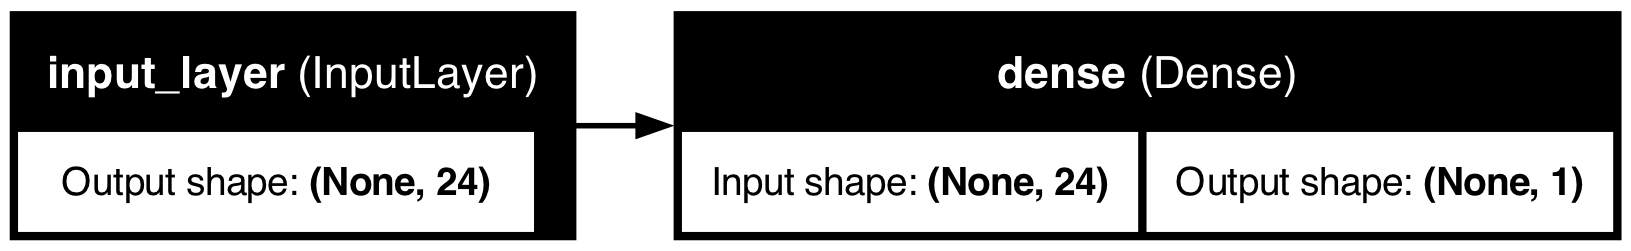

In [11]:
nn1 = util.build_nn_model(input_shape=(len(dt_in), ), output_shape=1, hidden=[])
util.plot_nn_model(nn1)

* We just need to specify that there are no hidden layers
* Why the simplest? As usual, due to [Occam's razor](https://en.wikipedia.org/wiki/Occam%27s_razor)

## Training

**It's useful to define a generic training function**

As usual, you can find it in the `util` module:

```python
def train_nn_model(model, X, y, loss,
        verbose=0, patience=10,
        validation_split=0.0, **fit_params):
    # Compile the model
    model.compile(optimizer='Adam', loss=loss)
    # Build the early stop callback
    cb = []
    if validation_split > 0:
        cb += [callbacks.EarlyStopping(patience=patience,
            restore_best_weights=True)]
    # Train the model
    history = model.fit(X, y, callbacks=cb, validation_split=validation_split,
            verbose=verbose, **fit_params)
    return history
```

## Training

**We can now train our model**

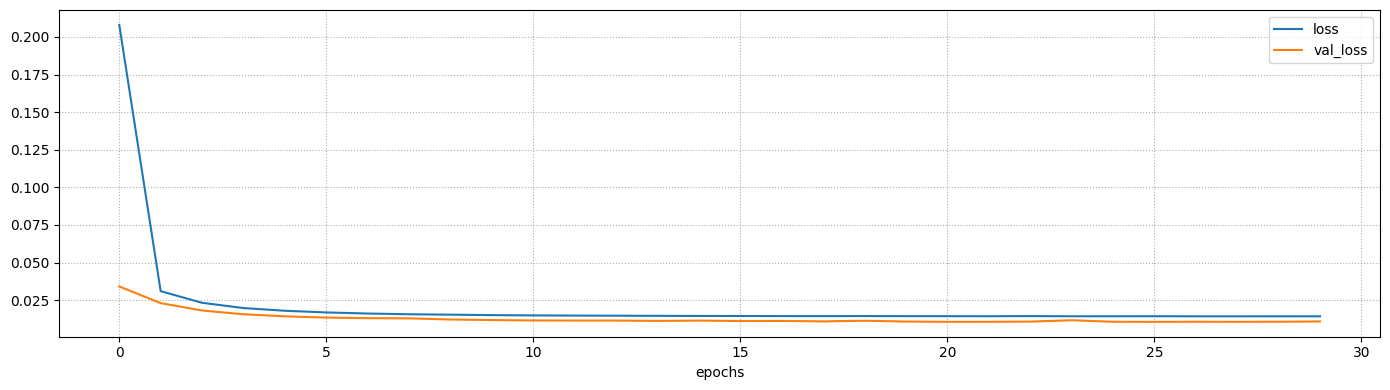

Final loss: 0.0142 (training), 0.0108 (validation)


In [12]:
nn1 = util.build_nn_model(input_shape=(len(dt_in), ), output_shape=1, hidden=[])
history = util.train_nn_model(nn1, tr_s[dt_in], tr_s['rul'], loss='mse', epochs=30, validation_split=0.2, batch_size=32)
util.plot_training_history(history, figsize=figsize)

## Training

**Let's try with a more complex model**

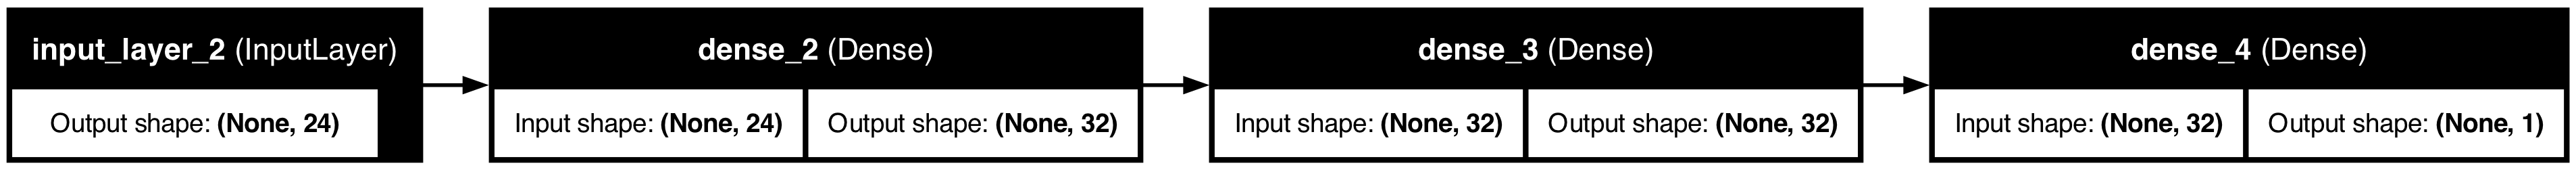

In [13]:
nn2 = util.build_nn_model(input_shape=(len(dt_in), ), output_shape=1, hidden=[32, 32])
util.plot_nn_model(nn2)

* Now we have two hidden layers
* ...Each with 32 ReLU neurons

## Training

**Let's check the loss behavior and compare it to Linear Regression**

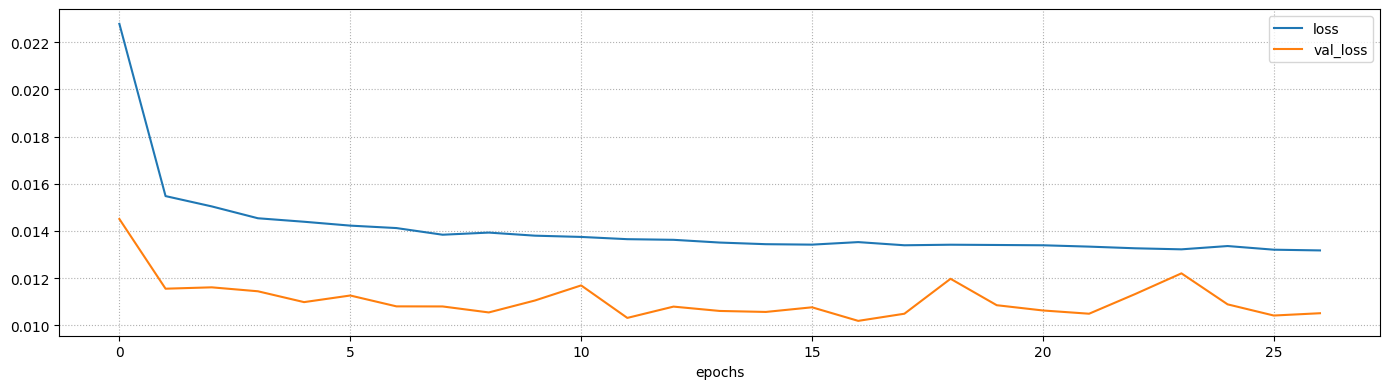

Final loss: 0.0132 (training), 0.0105 (validation)


In [14]:
nn2 = util.build_nn_model(input_shape=(len(dt_in), ), output_shape=1, hidden=[32, 32])
history = util.train_nn_model(nn2, tr_s[dt_in], tr_s['rul'], loss='mse', epochs=30, validation_split=0.2, batch_size=32)
util.plot_training_history(history, figsize=figsize)

* There is a modest improvement w.r.t. Linear Regression

## Predictions

**We can now obtain the predictions and evaluate their quality**

R2 score: 0.5399408691553765


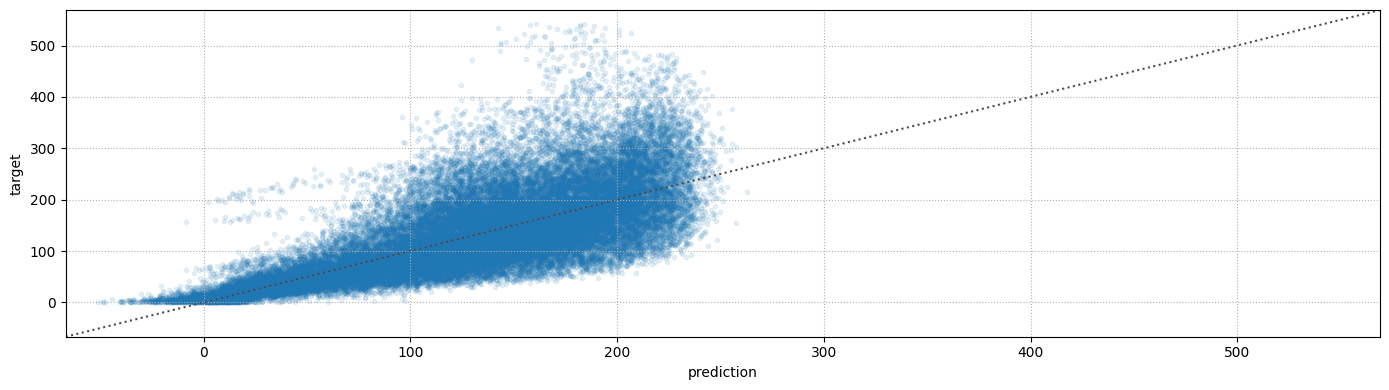

In [15]:
tr_pred = nn2.predict(tr_s[dt_in], verbose=0).ravel() * trmaxrul
util.plot_pred_scatter(tr_pred, tr['rul'], figsize=figsize)
print(f'R2 score: {r2_score(tr["rul"], tr_pred)}')

<div class=big>What do you think of these results?</div>

## Predictions

**The results so far are not comforting**

...But it's worth seeing what is going on over time:

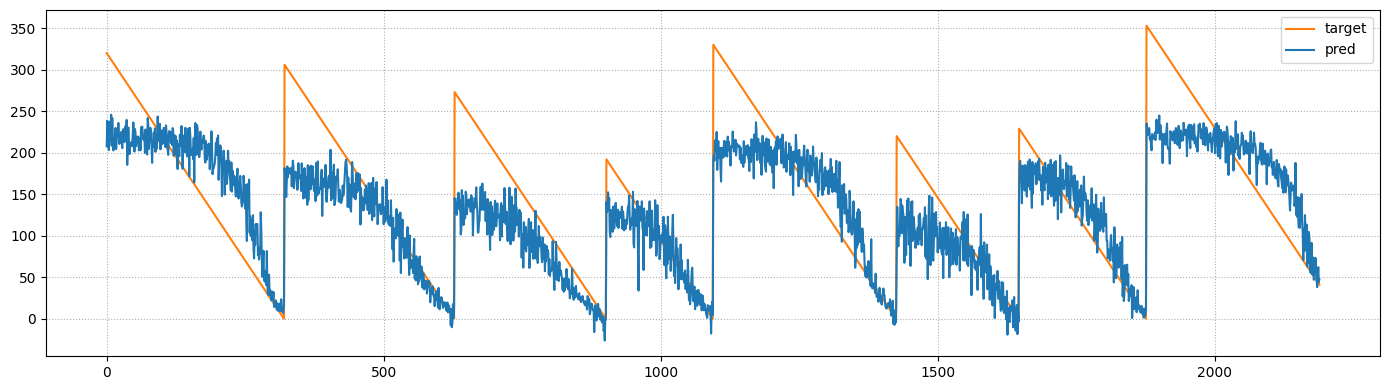

In [16]:
stop = 2*1095
util.plot_rul(tr_pred[:stop], tr['rul'][:stop], figsize=figsize)

## Predictions

**The situation is similar on the test set:**

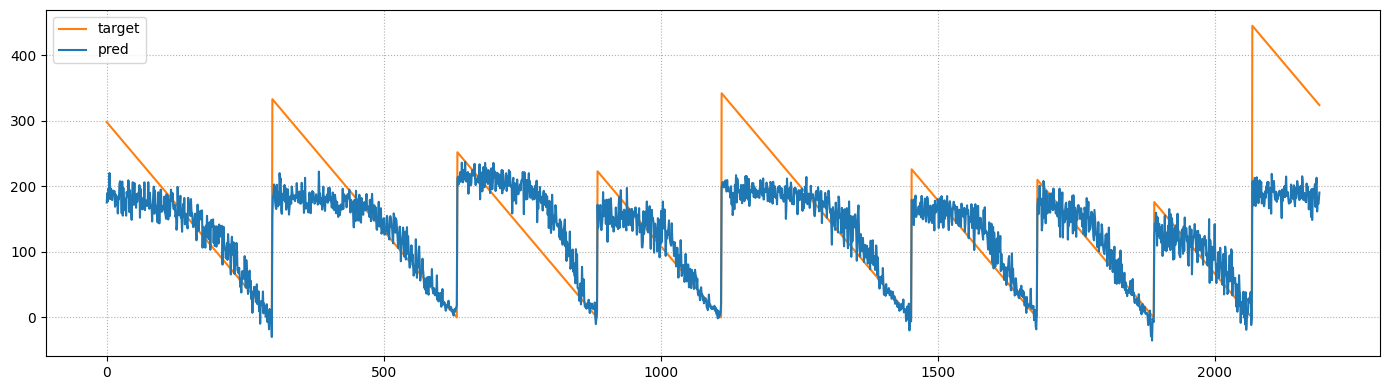

In [17]:
ts_pred = nn2.predict(ts_s[dt_in], verbose=0).ravel() * trmaxrul
util.plot_rul(ts_pred[:stop], ts['rul'][:stop], figsize=figsize)

## Quality Evaluation

**Let's try to recap the situation**

* Our accuracy is quite poor
* ...Especially for large RUL values

**Possible reasons:**

* Large RUL value are somewhat scarce on the dataset
* Fault effects become noticeable only after a while

**But perhaps we don't care! Our goal is _not a high accuracy_**

* We just need to _stop at the right time_
* ...And our model may still be good enough for that

> **For a proper evaluation, we need a _cost model_**

## Cost Model

**We will assume that:**

We consider one step of operation as our value unit

* ...So we can express the failure cost in terms of operating steps

Every run end with either failure or maintenance:

* Assuming that the failure cost is higher than maintenance cost
* ...We can diseregard the maintenance cost 

A traditional preventive maintenance policy is also available

* We will never trigger maintenance ealier that such policy
* We only gain value if we beat such policy

## Cost Model

**Slighly more formally:**

* One step of operation brings 1 unit of profit
* A failure costs $C$ units more than maintenance
* We only count what happens after $s$ steps


**Formally, let $x_k$ be the times series for machine $k$, and $I_k$ its set of time steps**

* The time step when our policy triggers maintenance is given by:
$$
\min \{i \in I_k \mid f(x_{ki}) < \varepsilon \}
$$
* A failure occurs if:
$$
f(x_{ki}) \geq \varepsilon \quad \forall i \in I_k
$$

## Cost Model

**The whole cost formula _for a single machine_ will be:**

$$
\mathit{cost}(f({x_k}), \varepsilon) = \mathit{op\_profit}(f(x_k), \varepsilon) + \mathit{fail\_cost}(f(x_k), \varepsilon)
$$

Where:

$$
\mathit{op\_profit}(f(x_k), \varepsilon) = -\max(0, \min \{i \in I_k \mid f(x_{ki}) < \varepsilon\}-s) \\
\mathit{fail\_cost}(f(x_k), \varepsilon) = \left\{
\begin{align}
& C \text{ if } f(x_{ki}) \geq \varepsilon \quad \forall i \in I_k \\
& 0 \text{ otherwise}
\end{align}
\right.
$$

* $s$ units of machine operation are guaranteed
* ...So we gain over the default policy only if we stop after that
* Profit is modeled as a negative cost

**For the total cost, we need to sum over all machines**

## Cost Model

**Normally, we would proceed as follows**

* $s$ is determined by the preventive maintenance schedule
* $C$ must be determined by discussing with the customer

In our example, we will derive both from data

**First, we collect all failure times**

In [18]:
failtimes = dt.groupby('machine')['cycle'].max()
failtimes.head()

machine
461    321
462    299
463    307
464    274
465    193
Name: cycle, dtype: int64

## Cost Model

**Then, we define $s$ and $C$ based on statistics**

In [19]:
print(failtimes.describe())
safe_interval = failtimes.min()
maintenance_cost = failtimes.max()

count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: cycle, dtype: float64


* For the safe interval $s$, we choose the minimum failure time
* For the maintenance cost $C$ we choose the largest failure time

## Threshold Choice

**We can then choose the threshold $\theta$ as usual**

Optimal threshold for the training set: 10


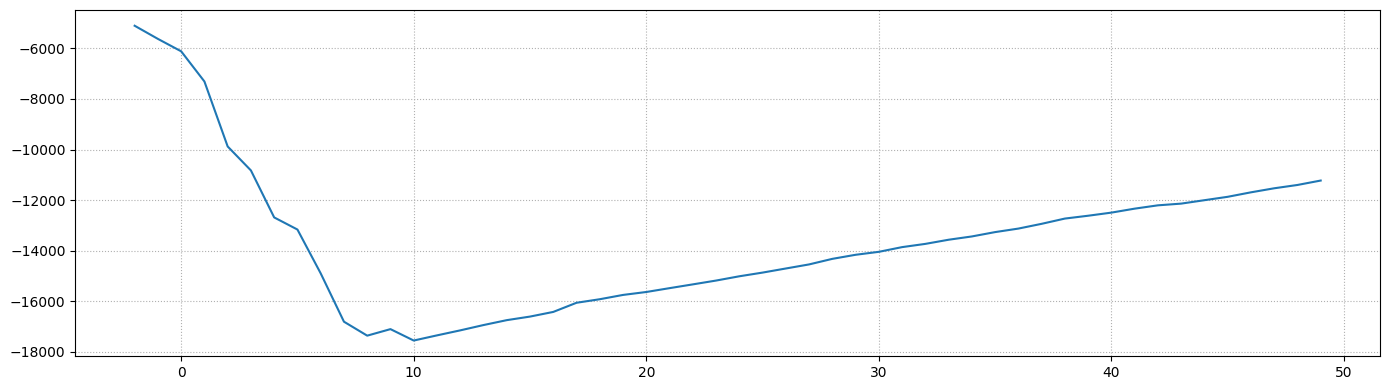

In [20]:
cmodel = util.RULCostModel(maintenance_cost=maintenance_cost, safe_interval=safe_interval)
th_range = np.arange(-2, 50)
tr_thr = util.opt_threshold_and_plot(tr['machine'].values, tr_pred, th_range, cmodel, figsize=figsize)
print(f'Optimal threshold for the training set: {tr_thr}')

## Evaluation

**Let's see how we fare in terms of cost**

In [21]:
tr_c, tr_f, tr_sl = cmodel.cost(tr['machine'].values, tr_pred, tr_thr, return_margin=True)
ts_c, ts_f, ts_sl = cmodel.cost(ts['machine'].values, ts_pred, tr_thr, return_margin=True)
print(f'Avg. cost: {tr_c/len(tr_mcn):.2f} (training), {ts_c/len(ts_mcn):.2f} (test)')

Avg. cost: -94.36 (training), -104.13 (test)


We can also evaluate the margin for improvement:

In [22]:
print(f'Avg. fails: {tr_f/len(tr_mcn)} (training), {ts_f/len(ts_mcn)} (test)')
print(f'Avg. slack: {tr_sl/len(tr_mcn):.2f} (training), {ts_sl/len(ts_mcn):.2f} (test)')

Avg. fails: 0.0 (training), 0.0 (test)
Avg. slack: 21.94 (training), 19.81 (test)


* Slack = distance between when we stop and the failure
* The results are actually quite good!
* ...And we also generalize fairly well

# Sequence Input in Neural Models

## Sequence Input in Neural Models

**Feeding more time steps to our NN might improve the results**

* Intuitively, sequences provide information about the _trend_
* This may allow a better RUL estimate w.r.t. using only the current state
* E.g. we may gauge how quickly the component is deteriorating

**We will try to build a model capable to processing such input**

But first, we need to apply a sliding window:

In [23]:
wlen = 3
tr_sw, tr_sw_m, tr_sw_r = util.sliding_window_by_machine(tr_s, wlen, dt_in)
ts_sw, ts_sw_m, ts_sw_r = util.sliding_window_by_machine(ts_s, wlen, dt_in)

* This must be done on a _per machine_ basis
* Windows _should not mix data_ belonging to different machines!

## Sliding Window for Multivariate Data

**The `sliding_window_by_machine` relies internally on:**

```python
def sliding_window_2D(data, wlen, stride=1):
    # Get shifted _tables_
    m = len(data)
    lt = [data.iloc[i:m-wlen+i+1:stride, :].values for i in range(wlen)]
    # Reshape to _add a new axis_
    s = lt[0].shape
    for i in range(wlen):
        lt[i] = lt[i].reshape(s[0], 1, s[1])
    # Concatenate
    wdata = np.concatenate(lt, axis=1)
    return wdata
```

* It's similar to our code for the univariate case
* The output is a tensor with shape `(n_windows, w_len, n_dims)`

## Sliding Window for Multivariate Data

**Let's look in deeper detail at the returned data structures**

`tr_sw` contain the actual sliding window data:

In [24]:
tr_sw[0]

array([[ 1.21931469,  0.86619169,  0.41983436, -1.05564063, -0.79621447,
        -0.70080293, -0.74549387, -1.1386061 , -1.08249848, -0.99389823,
        -0.11421637, -0.6315044 , -0.67586863, -0.36411574, -0.98910425,
         0.41889575,  0.08700467,  0.05991388, -0.69502688, -0.63793104,
        -0.11268403,  0.41983436, -1.03117521, -1.03187757],
       [-0.26962527,  0.41609996,  0.41983436,  0.6926385 ,  0.71397375,
         0.56288953,  0.29808726,  0.36365649,  0.3710279 ,  0.33249075,
         0.65388538,  0.56210134, -0.20641916,  0.32893584,  0.33156802,
         0.41687122, -0.24758681, -0.12925879, -0.69502688,  0.47652818,
         0.65613725,  0.41983436,  0.35321893,  0.35869109],
       [ 1.21924025,  0.86908928,  0.41983436, -1.05564063, -0.8157647 ,
        -0.70372248, -0.7109787 , -1.1386061 , -1.08433606, -0.98831315,
        -0.11380415, -0.64524209, -0.67586863, -0.37335643, -0.99026013,
         0.41874002, -0.00870947,  0.14931194, -0.69502688, -0.67388133,
  

* 3 times steps per example
* 24 dimensions per time step

## Sliding Window for Multivariate Data

**Let's look in deeper detail at the returned data structures**

`tr_sw_m` contains the corresponding machine values

In [25]:
tr_sw_m

array([461, 461, 461, ..., 708, 708, 708], shape=(45013,))

* The structure is a plain numpy array

`tr_sw_r` contains the RUL values

In [26]:
tr_sw_r

array([0.58671587, 0.58487085, 0.58302583, ..., 0.00369004, 0.00184502,
       0.        ], shape=(45013,))

* Again, the structure is a plain numpy array

## 1D Convolutions in Keras

**The chosen format is ideal for _1D convolutions_ in keras**

We have a function to build 1D convolutional model in the `util` module

```python
def build_cnn_model(input_shape, output_shape, wlen, conv=[], hidden=[], output_activation='linear'):
    model_in = keras.Input(shape=input_shape, dtype='float32')
    x = model_in
    for k in conv:
        x = layers.Conv1D(k, kernel_size=3, activation='relu')(x)
    x = layers.Flatten()(x)
    for k in hidden:
        x = layers.Dense(k, activation='relu')(x)
    x = layers.Dense(output_shape, activation=output_activation)(x)
    model = keras.Model(model_in, x)
    return model
```

* Each convolution in our code will consider 3 time steps
* We need to "flatten" the input before the fully connected layers
* Flattening = getting rid of the temporal structure

## 1D Convolutions in Keras

**Let's build a 1D convolutional model**

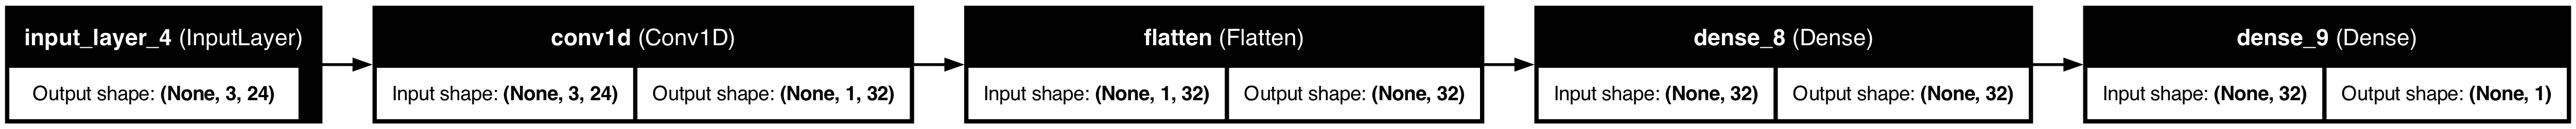

In [27]:
nn3 = util.build_cnn_model(input_shape=(wlen, len(dt_in)), output_shape=1, wlen=wlen, conv=[32], hidden=[32])
util.plot_nn_model(nn3)

* We have a single convlution with 32 kernels
* Then a hidden layer with 32 ReLU neurons
* ...And finally the output layer

## CNN Training

**Let's train our CNN**

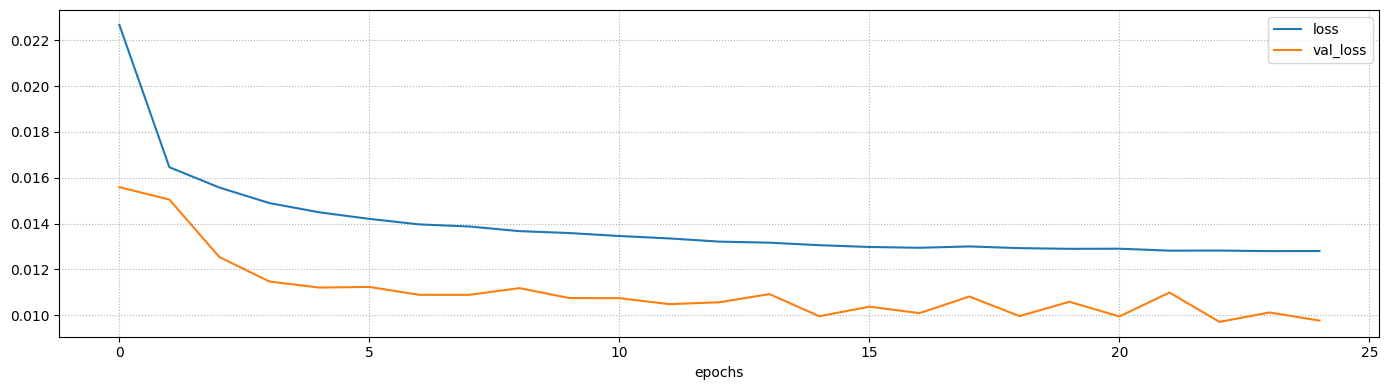

Final loss: 0.0128 (training), 0.0098 (validation)


In [28]:
nn3 = util.build_cnn_model(input_shape=(wlen, len(dt_in)), output_shape=1, wlen=wlen, conv=[32], hidden=[32])
history = util.train_nn_model(nn3, tr_sw, tr_sw_r, loss='mse', epochs=25, validation_split=0.2, batch_size=32)
util.plot_training_history(history, figsize=figsize)

* We obtained _a marginal improvement_
* This suggest that considering sequence be _modestly useful_ in this case

## Threshold Optimization

**Now we can proceed by choosing a threshold**

Optimal threshold for the training set: 11


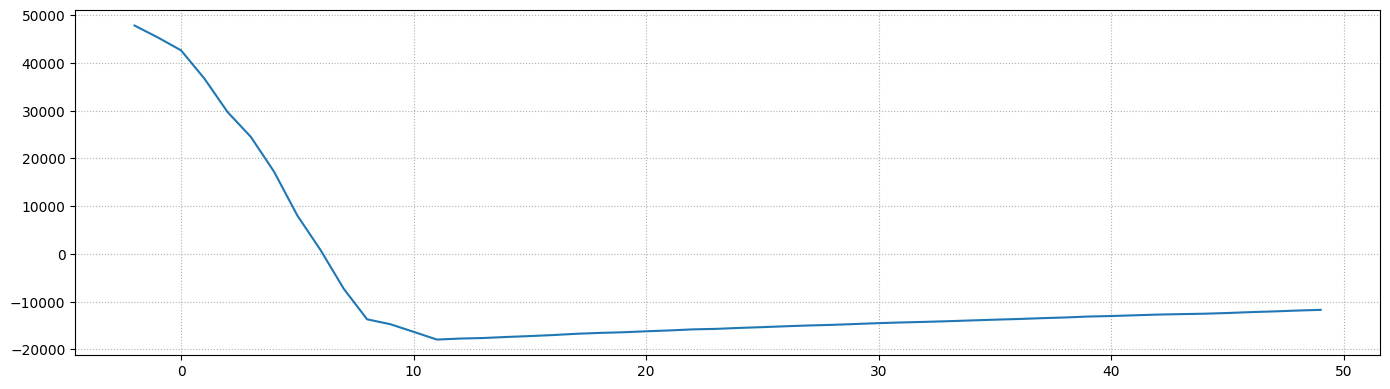

In [29]:
tr_pred3 = nn3.predict(tr_sw, verbose=0).ravel() * trmaxrul
ts_pred3 = nn3.predict(ts_sw, verbose=0).ravel() * trmaxrul
tr_thr3 = util.opt_threshold_and_plot(tr_sw_m, tr_pred3, th_range, cmodel, figsize=figsize)
print(f'Optimal threshold for the training set: {tr_thr3}')

## Evaluation

**Let's see how the CNN fares in terms of cost**

In [30]:
tr_c3, tr_f3, tr_sl3 = cmodel.cost(tr_sw_m, tr_pred3, tr_thr3, return_margin=True)
ts_c3, ts_f3, ts_sl3 = cmodel.cost(ts_sw_m, ts_pred3, tr_thr3, return_margin=True)
print(f'Cost: {tr_c3/len(tr_mcn):.2f} (training), {ts_c3/len(ts_mcn):.2f} (test)')
print(f'Avg. fails: {tr_f3/len(tr_mcn):.2f} (training), {ts_f3/len(ts_mcn):.2f} (test)')
print(f'Avg. slack: {tr_sl3/len(tr_mcn):.2f} (training), {ts_sl3/len(ts_mcn):.2f} (test)')

Cost: -96.51 (training), -107.13 (test)
Avg. fails: 0.00 (training), 0.00 (test)
Avg. slack: 17.86 (training), 14.68 (test)


Which is (more or less) on par with our MLP approach, for which we had:

In [31]:
print(f'Cost: {tr_c/len(tr_mcn):.2f} (training), {ts_c/len(ts_mcn):.2f} (test)')
print(f'Avg. fails: {tr_f/len(tr_mcn):.2f} (training), {ts_f/len(ts_mcn):.2f} (test)')
print(f'Avg. slack: {tr_sl/len(tr_mcn):.2f} (training), {ts_sl/len(ts_mcn):.2f} (test)')

Cost: -94.36 (training), -104.13 (test)
Avg. fails: 0.00 (training), 0.00 (test)
Avg. slack: 21.94 (training), 19.81 (test)


Which stresses a simple, but important point...

## Time Series and Sequence Input

**Just because you are dealing with time series**

...Do not assume that sequence input is useful!

* Sequences matter only if the output is correlated with patterns
* ...That involve multiple time steps

**In many practical problems**

...A single "state" encodes most of the useful information

* You can think of that as sort of Markov property

**Therefore, before using sequences, it makes sense to _think_**

Do you expect sequences to provide useful information?

* E.g. is there seom kind of inertia?
* ...And does it matter for the considered problem?